# Clustering with Sklearn

Clustering of unlabeled data can be performed with the Python module [sklearn.cluster](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.cluster)

This module offers more than 10 [clustering algorithms](https://scikit-learn.org/stable/modules/clustering.html) which include the widely used K-means, agglomerative and DBSCAN methods.


## Clustering of iris flowers

In [28]:
import numpy as np  # mathematical functions, random number generators, linear algebra routines, Fourier transforms, and more
import pandas as pd  # data analysis and manipulation tool
import matplotlib.pyplot as plt  #  static, animated, and interactive data visualizations
import seaborn as sns  # data visualization library based on matplotlib

import warnings  
warnings.filterwarnings('ignore')  # ignore warnings

In [29]:
from sklearn.cluster import KMeans 
from sklearn.cluster import AgglomerativeClustering

### Loading and exploring the data

Read the data (downloaded from [Kaggle](https://www.kaggle.com/code/khotijahs1/k-means-clustering-of-iris-dataset/data))

In [3]:
iris = pd.read_csv("Data/IRIS.csv")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Clustering will be only based on the numeric features

In [4]:
x = iris[iris.columns[:-1]]

In [30]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


#### Several scatterplot matrices

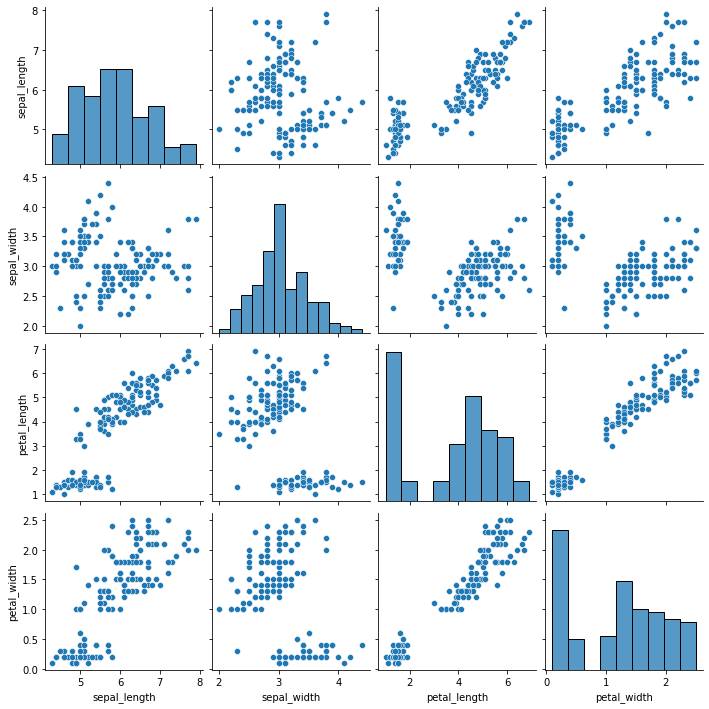

In [5]:
sns.pairplot(x)

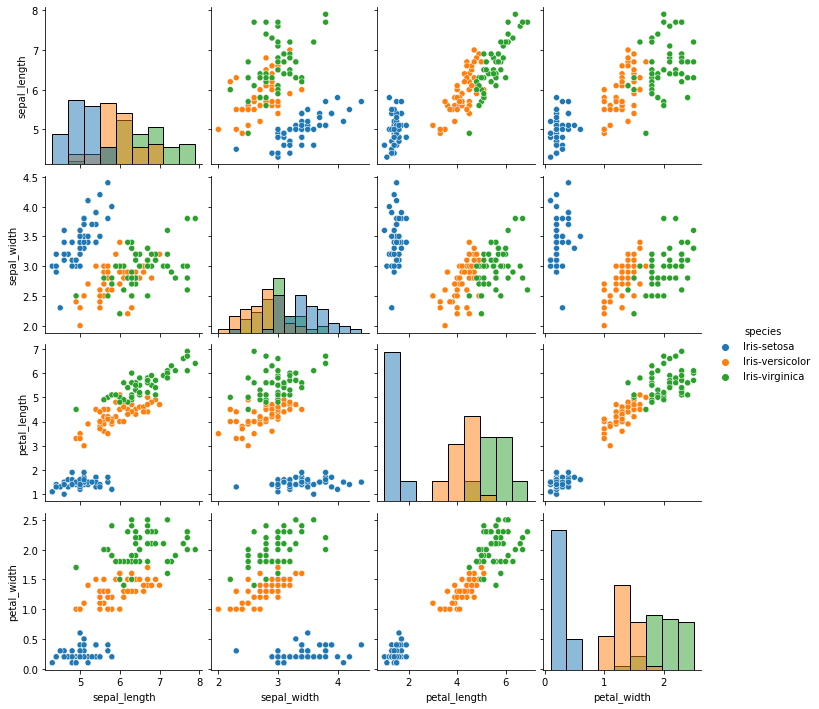

In [21]:
# Colouring 
sns.pairplot(iris, hue="species", diag_kind="hist")

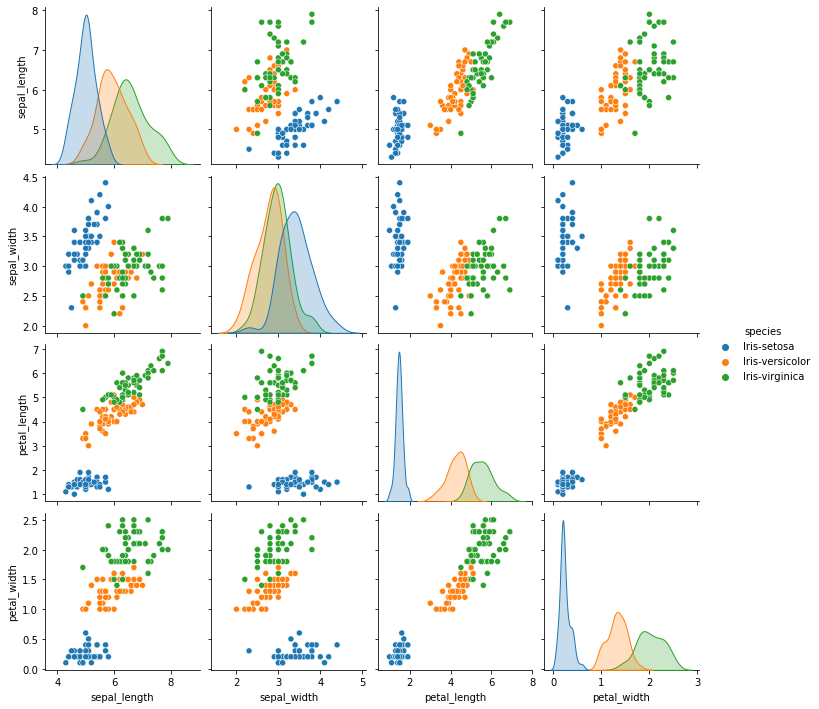

In [14]:
sns.pairplot(iris, hue="species")

* The setosa species is clearly more separated than the other two. 
* In terms of unsupervised clustering, the available features might not distinguish the versicolor and virginica species as two separated clusters. 
* Perhaps using more features might make the clustering more similar to the clustering in three species proposed by botanists.

## K-means clustering (KMC)

We will use the Sklearn Kmeans function which has the following input parameters and default values:

KMeans(n_clusters=8, *, init='k-means++', n_init='warn', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')

Some important parameters:

* n_clusters: Number of clusters to be found.
* n_init {‘auto’ or int}: Number of times the k-means algorithm is run with different centroid seeds.
* max_iter: Maximum number of iterations of the k-means algorithm for a single run.
* algorithm {“lloyd”, “elkan”, “auto”, “full”} K-means algorithm to use

* init {‘k-means++’, ‘random’}: Method to find the initial points to define clusters in an iterative manner. ‘k-means++’ selects initial cluster centroids using sampling based on an empirical probability distribution of the points’ contribution to the overall inertia. This technique speeds up convergence. 

The inertia is the sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided. In other words, the inertia in this terminology is the error used in the Mathematica lectures which was defined in terms of the quadratic Euclidean distances of each datum to the centroid of their cluster.

Let us assume a clustering of the data in $K$ clusters. Let $G_k$ be the $k$-th cluster and ${\bf c}^{(k)}$ its centre. The error of points within $G_k$ is given by the sum of the square the distance of each data point in $G_k$ to the centre of the cluster:

$\text{Error}^{(k)}= \sum_{i \in G_k} d^2({\bf x}^{(i)},{\bf c}^{(k)})$

The inertia or total error is then the sum of errors for each cluster:

$\text{Inertia} = \text{Error} = \sum_{k=1}^K \text{Error}^{(k)}$

### Scaling the data

Since KMC is based on distances, it may be convenient to scale the features before implementing KMC. `FindClusters` does it automatically in Mathematica but we have to do it manually here.

In [6]:
# One could scale using standardization or a MinMax scaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler = StandardScaler().fit(x) # Define a standardisation scaler
x_scaled = scaler.transform(x) # Transform the data.

`x_scaled` is a numpy array. In order to visualize a scatterplot matrix with the Seaborn package, we need to define a dataframe.

In [7]:
x_scaled_df = pd.DataFrame(data= x_scaled, columns = x.columns)
x_scaled_df

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977
...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956
146,0.553333,-1.281972,0.705893,0.922064
147,0.795669,-0.124958,0.819624,1.053537
148,0.432165,0.800654,0.933356,1.447956


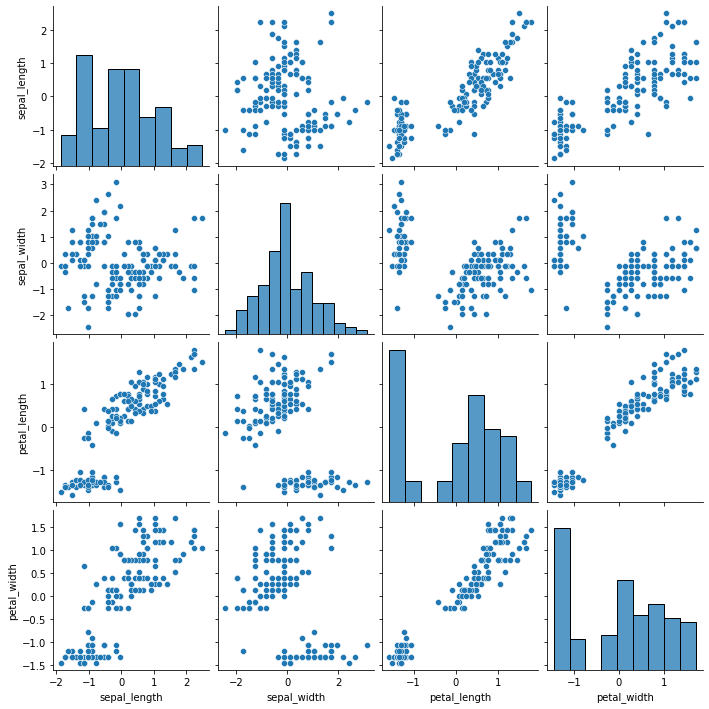

In [29]:
# Visualise the transformed data
sns.pairplot(x_scaled_df)

### KMC for 3 clusters

In [8]:
# Define the model
kmeans = KMeans(n_clusters = 3)

# Fit it to the data, analogous to FindClusters in Mathematica
kmeans.fit(x_scaled_df)

KMeans(n_clusters=3)

This is analogous to 

FindClusters[x, 3, Method -> "KMeans", DistanceFunction -> EuclideanDistance];

in Mathematica.

One can interrogate the fitted clustering model as follows:

In [9]:
kmeans.get_params()

{'algorithm': 'auto',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [10]:
kmeans.cluster_centers_

array([[ 1.13597027,  0.09659843,  0.996271  ,  1.01717187],
       [-1.01457897,  0.84230679, -1.30487835, -1.25512862],
       [-0.05021989, -0.88029181,  0.34753171,  0.28206327]])

In [11]:
# Inertia (Error) of the clustering
kmeans.inertia_

140.96581663074699

In [14]:
# Labels of each point
# Analogous to the labels obtained with ClusterClassify in Mathematica
labels = kmeans.labels_
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2])

### Performance evaluation
One can use several metrics to evaluate the performance of the clustering (see explicit definitions [here](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation)). The larger these indices, the better the clustering.

For the KMC with $K=3$ clusters studied above:

In [12]:
from sklearn import metrics

In [15]:
metrics.calinski_harabasz_score(x_scaled_df, labels)

239.34180132491102

In [16]:
metrics.davies_bouldin_score(x_scaled_df, labels)

0.8354098493935597

In [17]:
metrics.silhouette_score(x_scaled_df, labels)

0.4589717867018717

One can see the predicted classes on a scatterplot to compare with the scatterplot colored by the true classes presented above

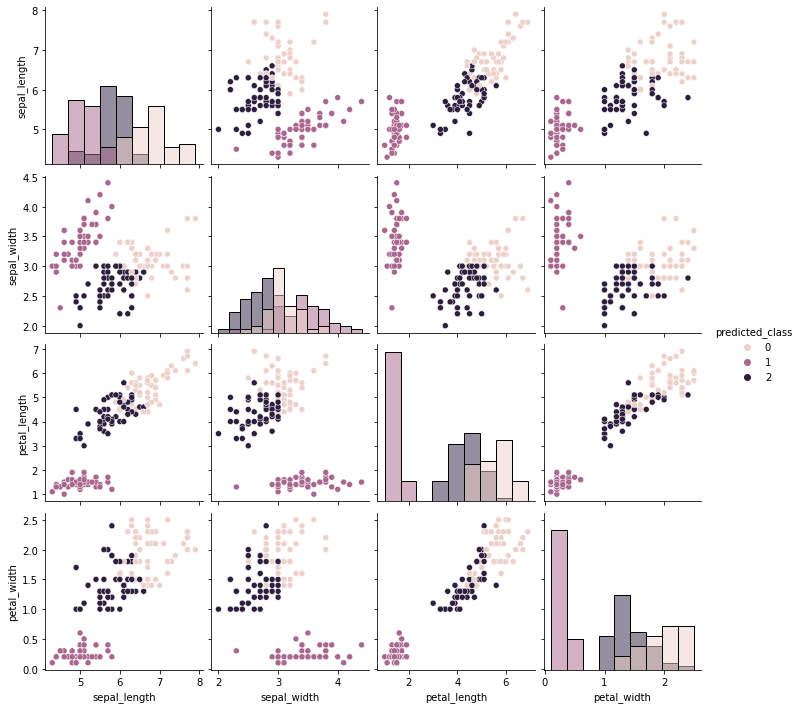

In [20]:
# Create a dataframe with the features and a column with the predicted labels
iris_predicted = iris[iris.columns[:-1]]
iris_predicted['predicted_class'] = labels

sns.pairplot(iris_predicted, hue="predicted_class", diag_kind="hist")

Here one can see that the two classes with largest overlap (0 and 2) are more separated than the virginica and versicolor species in the true classification. This suggests that the predicted classes 0 and 2 will somehow mix the virginica and versicolor species. This is not necessarily a defect of the clustering algorithm but just a consequence that the available features do not allow the virginica and versicolor species to be fully separated.

Let us compare the clustering and actual classes in a more quantitative manner.

#### Comparing with the true labels - Similar to what we did with ClusterClassify in Mathematica

In [22]:
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics.cluster import rand_score

labels_true = iris['species']
labels_pred = labels

[Rand index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html#sklearn.metrics.rand_score) - A purity index taking values between 0 (full disagreement with true labels) and 1 (full agreement)

In [23]:
rand_score(labels_true, labels_pred)

0.8322147651006712

[Contingency matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cluster.contingency_matrix.html#sklearn.metrics.cluster.contingency_matrix) reports the intersection cardinality for every true/predicted cluster pair. The contingency matrix provides sufficient statistics for all clustering metrics where the samples are independent and identically distributed and one doesn’t need to account for some instances not being clustered.

The element $C_{i,j}$ gives the of samples in true class $i$ and in predicted class $j$.

In [24]:
contingency_matrix(labels_true, labels_pred)

array([[ 0, 50,  0],
       [11,  0, 39],
       [36,  0, 14]], dtype=int64)

Text(33.0, 0.5, 'True class')

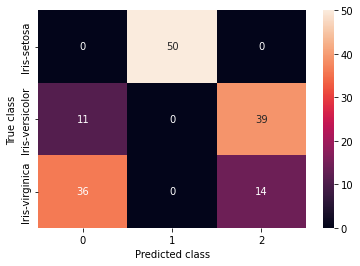

In [34]:
s = sns.heatmap(contingency_matrix(labels_true, labels_pred),annot=True, fmt=".0f",xticklabels=np.sort(iris_predicted['predicted_class'].unique()), yticklabels=iris['species'].unique())  # Here the format ensures that no scientific notation is used for the numbers
s.set_xlabel('Predicted class', fontsize=10)
s.set_ylabel('True class', fontsize=10)

One of the clusters contains all the examples from the first species (setosa) which is very separated from the other two species. The other two clusters contain a mixture of examples from the virginica and versicolor species that are not so well differentiated in terms of the available morphological features.

### Selection of the "optimal" number of clusters, $K$

#### Scree plot

Also called *Elbow plot*

Inertia (error) as a function the number of clusters $K$

Text(0, 0.5, 'Error')

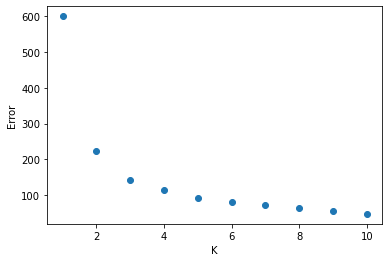

In [25]:
error = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(x_scaled_df)
    error.append(kmeans.inertia_)
    
plt.plot(range(1,11),error,'o')
plt.xlabel('K')
plt.ylabel('Error')

There is no clear shoulder for any value of k. However, the error does not decrease significantly for k>3. Therefore, k=3 is a reasonable value for the number of clusters.

#### Looking at the maximum of the clustering metrics

In [26]:
CH = [] #Calinski-Harabasz
DB = [] #Davies-Bouldin
Sil = [] #Silhouette

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(x_scaled_df)
    labels = kmeans.labels_
    
    CH.append(metrics.calinski_harabasz_score(x_scaled_df, labels))
    DB.append(metrics.davies_bouldin_score(x_scaled_df, labels))
    Sil.append(metrics.silhouette_score(x_scaled_df, labels))
    
KmaxCH = K_range[np.argmax(CH)]
KmaxDB = K_range[np.argmax(DB)]
KmaxSil = K_range[np.argmax(Sil)]

print('K with maximum Calinski-Harabasz index: ', KmaxCH)
print('K with maximum Davies-Bouldin index: ', KmaxDB)
print('K with maximum Silhouette index: ', KmaxSil)

K with maximum Calinski-Harabasz index:  2
K with maximum Davies-Bouldin index:  6
K with maximum Silhouette index:  2


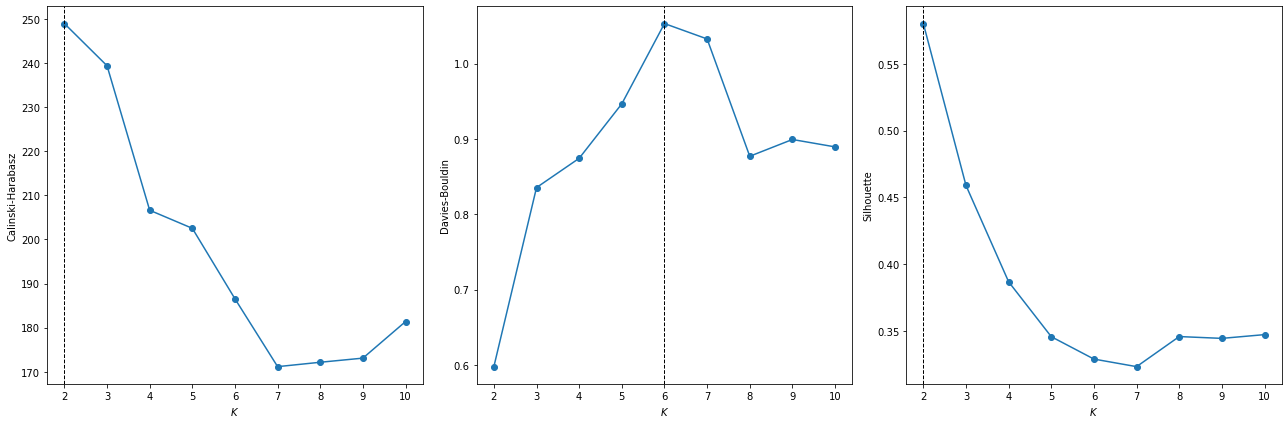

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.plot(K_range,CH,'o-')
ax1.set_xlabel('$K$')
ax1.set_ylabel('Calinski-Harabasz')
ax1.axvline(x = K_range[np.argmax(CH)], color = 'black', ls='--', lw=1, label = 'axvline - full height')

ax2.plot(K_range,DB,'o-')
ax2.set_xlabel('$K$')
ax2.set_ylabel('Davies-Bouldin')
ax2.axvline(x = K_range[np.argmax(DB)], color = 'black', ls='--', lw=1, label = 'axvline - full height')

ax3.plot(K_range,Sil,'o-')
ax3.set_xlabel('$K$')
ax3.set_ylabel('Silhouette')
ax3.axvline(x = K_range[np.argmax(Sil)], color = 'black', ls='--', lw=1, label = 'axvline - full height')


plt.tight_layout()

# Task for you:

Try other clustering methods such as agglomerative or DBSCAN to analyse the iris data. You can make a copy of this notebook to study other methods separately and assess the clustering performance as done here for the KMC method.